# Import

In [1]:
import os
import sys
import glob
sys.path.append("../../src")
import pickle
import numpy as np
import scanpy as sc
import pandas as pd
import seaborn as sns
import PIL.Image as Image
import matplotlib.pyplot as plt
from util.patch import *
from util.predict import *
from util.cluster import *
from util.seed import seed_torch
from util.mask2png import MaskRds2png
from FeatureExtraction.feature import extract_features, load_features
from PredictionModule.solver import TumorSolver, GeneSolver


In [2]:
seed = 42
seed_torch(seed)
Image.MAX_IMAGE_PIXELS = 100000000000

sample_list = ['CRC1','CRC2','M1042T']
gene_list = list(pd.read_csv('../data/gene_list/CRC_SVG346_list.txt',header=None).iloc[:,0])
print(f"Samples num:{len(sample_list)}",
      f"Gene num:{len(gene_list)}")

HE_dir = "../data/HE"
position_dir = "../data/tissue_positions_list"
scalefactor_dir = "../data/scale_factor"

Samples num:3 Gene num:346


# images to patches

In [3]:
for sample_id in sample_list:
    print(sample_id, "start")
    HE_path = os.path.join(HE_dir,sample_id+".jpg")
    position_path = os.path.join(position_dir,sample_id+".csv")
    scalefactor_path = os.path.join(scalefactor_dir,sample_id+".csv")
    tile_fullres(
        HE_path,
        out_path = "../output/tile",
        sample_id = sample_id,
        position_path = position_path,
        scalefactor_path = scalefactor_path)

CRC1 start


Tiling image: 100%|██████████ [ time left: 00:00 ]


CRC2 start


Tiling image: 100%|██████████ [ time left: 00:00 ]


M1042T start


Tiling image: 100%|██████████ [ time left: 00:00 ]


# Extract patch features

In [4]:
all_sample_features = extract_features(
                            tile_path = '../output/tile',
                            img_ids = sample_list,
                            model_weight_path = '../../resource/ctranspath.pth',
                            save = True,
                            seed = seed,
                            file = '../output/features/all_sample_features.pkl')

/home/bejsernia/miniconda3/envs/HiST_test1/lib/python3.8/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1724789116784/work/aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/home/bejsernia/project/HiST_git/HiST/demo/notebook/../../src/FeatureExtraction/feature.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects 

Extracting Feature Time Cost: 0.582087 min


Tumor model start training
Log and model weights will be saved at ../output/model/tumor/checkpoint_loo/202510271532


Training:   0%|           [ time left: ? ]/home/bejsernia/project/HiST_git/HiST/demo/notebook/../../src/PredictionModule/solver.py:188: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental fe

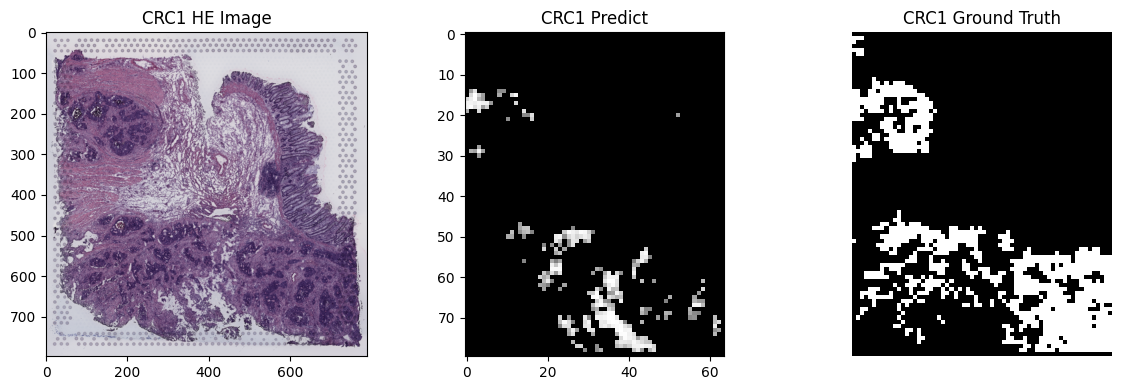

Training:  33%|███▎       [ time left: 01:02 ]

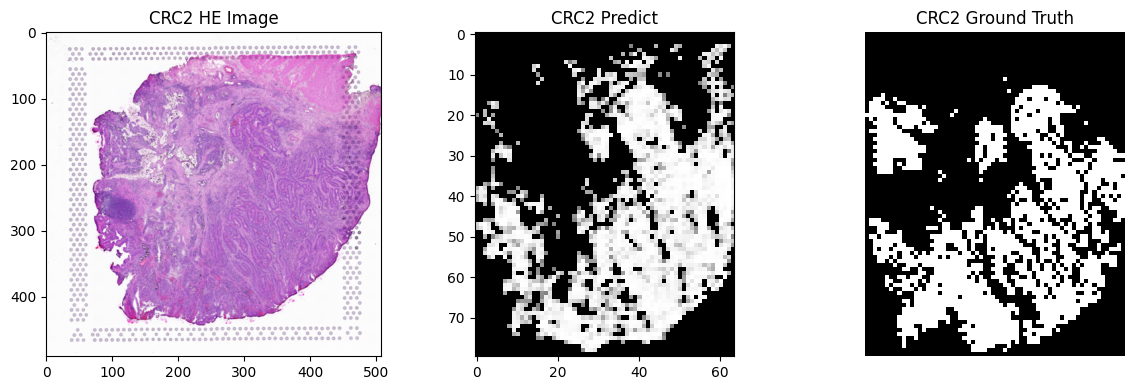

Training:  67%|██████▋    [ time left: 00:31 ]

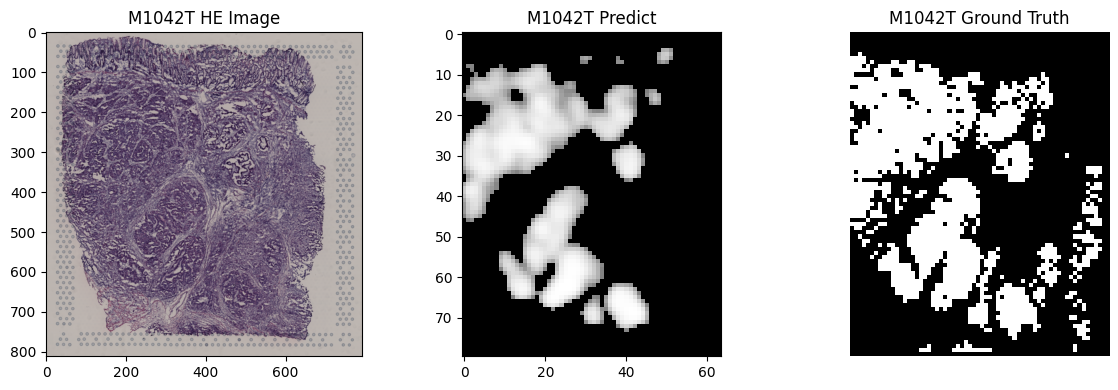

Training: 100%|██████████ [ time left: 00:00 ]

Predicted masks are saved at ../output/model/tumor/checkpoint_loo/202510271532/predict_masks
Training is done!


In [5]:
print("Tumor model start training")
Tumorsolver = TumorSolver(
    seed = seed,
    mask_ch=1, img_ch=768, epochs=200, lr=0.001, weight_decay=1e-4, verbose=False
)

Tumorsolver.train_loo(
    sample_list=sample_list,
    all_sample_features=all_sample_features,
    batch_size=1,
    mask_dir='../data/mask_png',
    mask_ext='.png',
    HE_path='../data/HE',
    HE_ext='.jpg',
    out_dir='../output/model/tumor/checkpoint_loo/'
)

/tmp/ipykernel_937287/3287350609.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=plt.cm.get_cmap('Set3'),


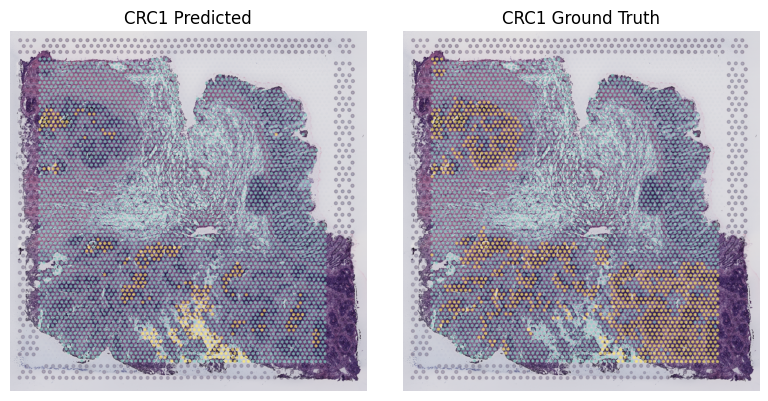

/tmp/ipykernel_937287/3287350609.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=plt.cm.get_cmap('Set3'),


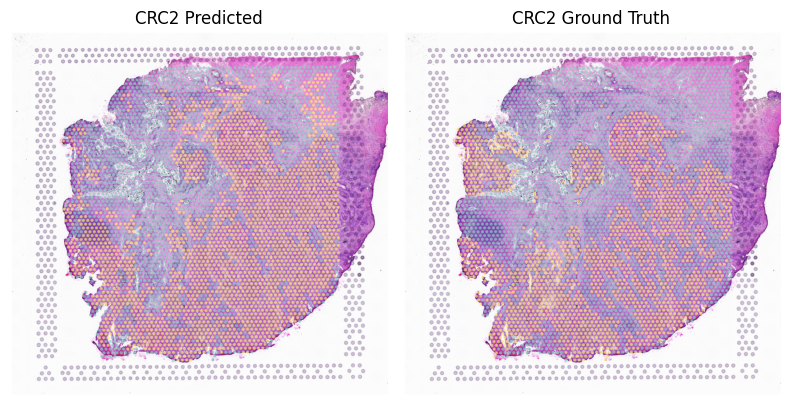

/tmp/ipykernel_937287/3287350609.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=plt.cm.get_cmap('Set3'),


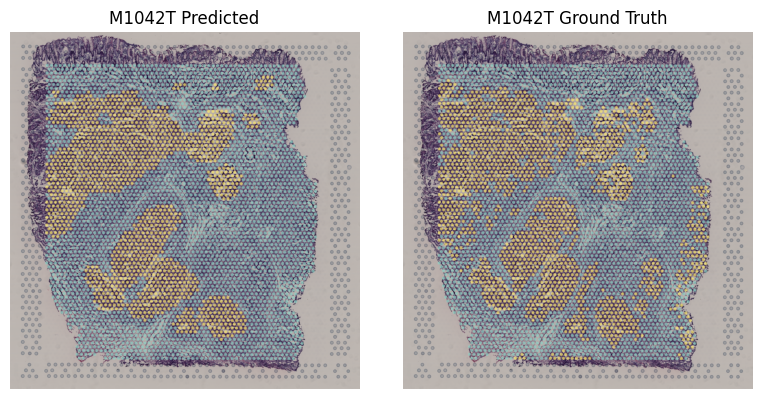

In [6]:
checkpoint_dir = '../output/model/tumor/checkpoint_loo/'
subdirs = [d for d in os.listdir(checkpoint_dir) if os.path.isdir(os.path.join(checkpoint_dir, d))]
subdirs.sort(key=lambda x: os.path.getmtime(os.path.join(checkpoint_dir, x)))
latest_dir = subdirs[-1]

with open(os.path.join(checkpoint_dir, latest_dir,'predict_masks/predict_masks.pkl'), 'rb') as f:
    predict_masks = pickle.load(f)
    
for sample in sample_list:
    VisualizeTumorST(
            sample_id=sample,
            sample_list=sample_list,
            predict_masks=predict_masks,
            tissue_positions_path = '../data/tissue_positions_list/',
            scale_factor_path = '../data/scale_factor/',
            HE_path = '../data/HE/',
            mask_path = '../data/mask_png/0/',
            img_format = '.jpg',
            scale = True,
            predict=True,
            compare=True,
            alpha=0.5,
            cmap=plt.cm.get_cmap('Set3'),
            title=True,
            out_dir=os.path.join(checkpoint_dir, latest_dir,'predict_results')
    )

In [7]:
print("Gene model start training")
Genesolver = GeneSolver(
    seed = seed,
    img_ch=768, epochs=200, lr=0.001, weight_decay=1e-4, verbose=False
)

Genesolver.train_loo(
        gene_list=gene_list,
        sample_list=sample_list,
        all_sample_features=all_sample_features,
        batch_size=1,
        gene_dir='../data/geneMatrix/',
        out_dir='../output/model/gene/checkpoint_loo/'
)

Gene model start training
Log and model weights will be saved at ../output/model/gene/checkpoint_loo/202510271534


Training: Leave CRC1 as validation:   0%|           [ time left: ? ]

Training: Leave M1042T as validation: 100%|██████████ [ time left: 00:00 ]

Correlation results are saved at ../output/model/gene/checkpoint_loo/202510271534/cor_df
Mean Pearson Correlation: 0.4636891566198321
Mean Spearman Correlation: 0.30205449152878927
Training is done!


In [8]:
checkpoint_dir = '../output/model/gene/checkpoint_loo/'
subdirs = [d for d in os.listdir(checkpoint_dir) if os.path.isdir(os.path.join(checkpoint_dir, d))]
subdirs.sort(key=lambda x: os.path.getmtime(os.path.join(checkpoint_dir, x)))
latest_dir = subdirs[-1]

pearson_df = pd.read_csv(os.path.join(checkpoint_dir, latest_dir,f'cor_df/pearson_cor.csv'),index_col=0)
print("Top 10 genes with high Pearson correlation:",pearson_df.mean(axis = 1).sort_values(ascending = False).head(10))

spearman_df = pd.read_csv(os.path.join(checkpoint_dir, latest_dir,f'cor_df/spearman_cor.csv'),index_col=0)
print("Top 10 genes with high Spearman correlation:",spearman_df.mean(axis = 1).sort_values(ascending = False).head(10))

Top 10 genes with high Pearson correlation: TMSB10    0.934628
EEF1A1    0.931200
FTH1      0.905851
S100A6    0.897740
ACTB      0.897447
B2M       0.893019
TPT1      0.880822
TMSB4X    0.879193
FTL       0.874881
ACTG1     0.874310
dtype: float64
Top 10 genes with high Spearman correlation: COL1A1    0.504067
COL1A2    0.500690
COL3A1    0.484245
FXYD3     0.483955
MYL9      0.480224
FTL       0.479227
SPARC     0.478664
MYL6      0.474292
LGALS4    0.469148
LGALS1    0.468226
dtype: float64


/home/bejsernia/project/HiST_git/HiST/demo/notebook/../../src/util/predict.py:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cmu_model.load_state_dict(torch.load(model_pa

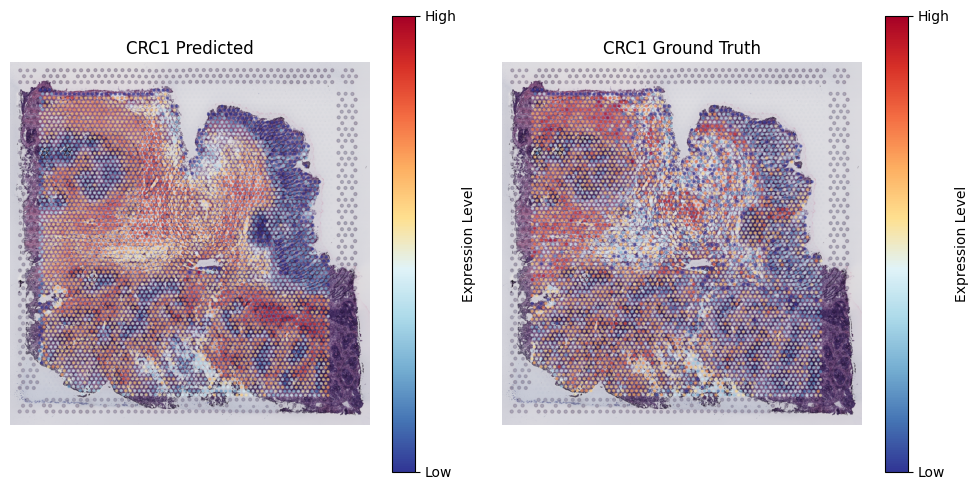

/home/bejsernia/project/HiST_git/HiST/demo/notebook/../../src/util/predict.py:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cmu_model.load_state_dict(torch.load(model_pa

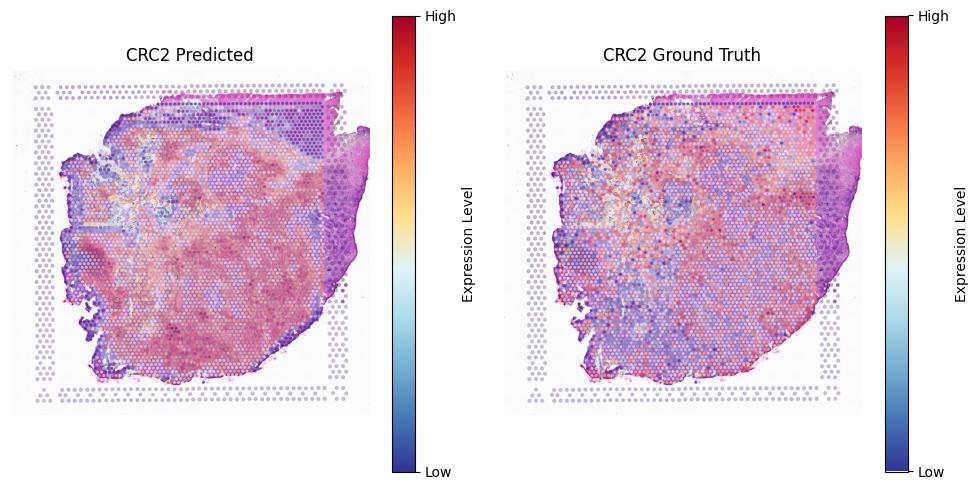

/home/bejsernia/project/HiST_git/HiST/demo/notebook/../../src/util/predict.py:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cmu_model.load_state_dict(torch.load(model_pa

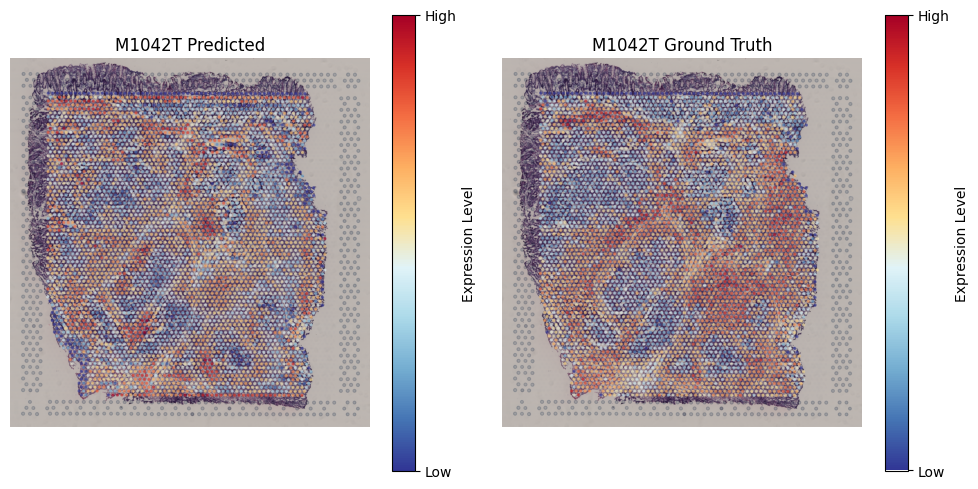

In [9]:
for sample in sample_list:
    VisualizeGeneST(
        sample_id=sample,
        sample_list=sample_list,
        gene='ACTB',
        gene_list=gene_list,
        all_sample_features=all_sample_features,
        model_path=os.path.join(checkpoint_dir, latest_dir,f'last_model/{sample}_200_model.pth'),
        rds_path='../data/geneMatrix/',
        tissue_positions_path = '../data/tissue_positions_list/',
        scale_factor_path = '../data/scale_factor/',
        HE_path = '../data/HE/',
        img_format='.jpg',
        scale = True,
        predict=True,
        compare=True,
        alpha=0.5,
        title=True,
        out_dir=os.path.join(checkpoint_dir, latest_dir,'visualization')
    )

/tmp/ipykernel_937287/1248479331.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


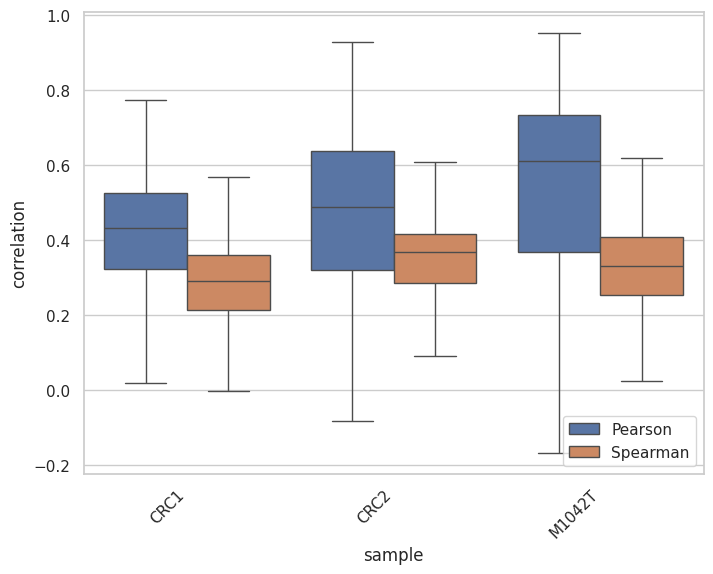

In [10]:
plot_df = pd.concat([pearson_df,spearman_df],keys = ('Pearson','Spearman'))
plot_df = plot_df.stack()
plot_df = plot_df.rename_axis(index = ['cor','gene','sample'])
plot_df = plot_df.reset_index(level = [0,2], name = 'correlation')
sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))
ax = sns.boxplot(data = plot_df, x='sample', hue = 'cor' ,y = 'correlation',showfliers = False)
ax.legend(loc='lower right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.figure.savefig(os.path.join(checkpoint_dir, latest_dir,'visualization',"loo_correlation_benchmark.pdf"),bbox_inches = 'tight')


/tmp/ipykernel_937287/2020089417.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


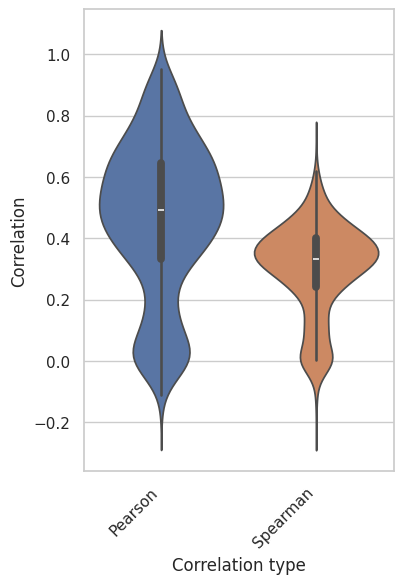

In [11]:
df1_list = pearson_df.values.flatten().tolist()
df2_list = spearman_df.values.flatten().tolist()

new_df = pd.DataFrame({'Pearson': df1_list,
                       'Spearman': df2_list})

plt.figure(figsize=(4, 6))
ax = sns.violinplot(data=new_df)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
sns.set(style="whitegrid")
ax.set_xlabel('Correlation type')
ax.set_ylabel('Correlation')
ax.figure.savefig(os.path.join(checkpoint_dir, latest_dir,'visualization',"violin_correlation_benchmark.pdf"),bbox_inches = 'tight')

# Figure3b HiST gene prediction reproduction

/home/bejsernia/project/HiST_git/HiST/demo/notebook/../../src/util/predict.py:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cmu_model.load_state_dict(torch.load(model_pa

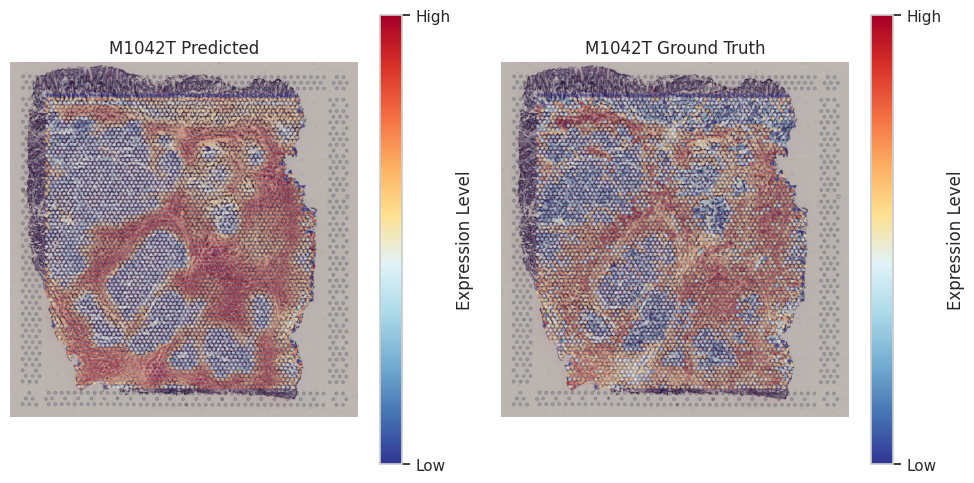

In [12]:
VisualizeGeneST(
    sample_id='M1042T',
    sample_list=sample_list,
    gene='ACTB',
    gene_list=gene_list,
    all_sample_features=all_sample_features,
    model_path='../data/model_weights/M1042T_200_model.pth',
    rds_path='../data/geneMatrix',
    tissue_positions_path='../data/tissue_positions_list',
    scale_factor_path='../data/scale_factor',
    HE_path='../data/HE',
    img_format='.jpg',
    scale = True,
    predict=True,
    compare=True,
    alpha=0.5,
    title=True,
    out_dir='../output/reproduction_Figure3b'
)